
<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/09_Lab_Hopfield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio: Memorias asociativas con redes de Hopfield

## Objetivo

Construir una red de Hopfield capaz de almacenar imágenes binarias y recuperar una imagen original a partir de una versión con ruido.


# Actividades

Para las imágenes dadas, construya un algoritmo que permita recuperar la imagen original a partir de una imagen perturbada.

Debe implementar funciones para:

1. Convertir una imagen binaria en un vector de estados.
2. Calcular la matriz de pesos de Hopfield.
3. Calcular el campo local que siente una neurona.
4. Actualizar el estado de una neurona.
5. Calcular la energía total de la red.
6. Aplicar ruido a una imagen.
7. Recuperar la imagen mediante actualización asincrónica aleatoria.

---

# Modelo de Hopfield

La matriz de pesos se define mediante la regla de Hebb:

$$
w_{ij}=\frac{1}{N}\sum_{\mu=1}^{P}\xi_i^\mu \xi_j^\mu
$$

con:

$$
w_{ii}=0
$$

donde:

- $N$ es el número total de píxeles,
- $P$ es el número de patrones almacenados,
- $\xi^\mu$ es el patrón $\mu$-ésimo.

---

# Campo local

Para una neurona $i$, el campo local es:

$$
h_i=\sum_j w_{ij}s_j
$$

Este campo representa la influencia colectiva que todas las demás neuronas ejercen sobre la neurona $i$.

---

# Regla de actualización

La actualización determinista de Hopfield es:

$$
s_i \leftarrow \mathrm{sign}(h_i)
$$

Si:

$$
h_i>0
$$

entonces:

$$
s_i=1
$$

Si:

$$
h_i<0
$$

entonces:

$$
s_i=-1
$$

---

# Energía de la red

La energía total del sistema se define como:

$$
E(s)=-\frac{1}{2}\sum_{ij}w_{ij}s_is_j
$$

o equivalentemente:

$$
E(s)=-\frac{1}{2}s^TWs
$$

El proceso de recuperación debe tender a disminuir la energía.

---

# Algoritmo sugerido

Dada una imagen con ruido:

1. Seleccione aleatoriamente un píxel $i$.
2. Calcule el campo local:

$$
h_i=\sum_j w_{ij}s_j
$$

3. Actualice el estado del píxel:

$$
s_i \leftarrow \mathrm{sign}(h_i)
$$

4. Calcule la nueva energía del sistema:

$$
E(s)=-\frac{1}{2}s^TWs
$$

5. Visite otro píxel aleatoriamente.
6. Repita el proceso hasta que:
   - la imagen deje de cambiar,
   - la energía se estabilice,
   - o se alcance un número máximo de iteraciones.


# Comentario importante

La actualización debe ser preferiblemente **asincrónica y aleatoria**, porque cada vez que se actualiza un píxel, cambia el estado global de la red. Por tanto, el siguiente campo local debe calcularse usando la imagen ya actualizada.

---

# Preguntas guía

1. ¿La energía disminuye durante la recuperación?
2. ¿La red recupera exactamente la imagen original?
3. ¿Qué ocurre si aumenta el nivel de ruido?
4. ¿Qué pasa si se almacenan varias imágenes?
5. ¿Aparecen estados espurios?
6. ¿La recuperación depende del orden en que se actualizan los píxeles?
7. ¿Qué diferencia hay entre actualización sincrónica y asincrónica?

---

# Capacidad de memoria

La capacidad aproximada de una red de Hopfield clásica es:

$$
P_c \approx 0.138N
$$

donde:

- $P_c$ es el número máximo de patrones recuperables,
- $N$ es el número total de neuronas.

Cuando el número de patrones almacenados supera este valor, aparecen errores y estados espurios.




In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def patrones_balanceados(n, m):
    horizontal = -np.ones((n, m))
    horizontal[:n//2, :] = 1

    vertical = -np.ones((n, m))
    vertical[:, :m//2] = 1

    checker = np.indices((n, m)).sum(axis=0)
    checker = np.where(checker % 2 == 0, 1, -1)

    return horizontal, vertical, checker

def agregar_ruido(s, frac=0.25, seed=None):
    if seed is not None:
        np.random.seed(seed)

    s_ruido = s.copy()
    N = len(s)

    n_flip = int(frac * N)
    idx = np.random.choice(N, n_flip, replace=False)

    s_ruido[idx] *= -1

    return s_ruido

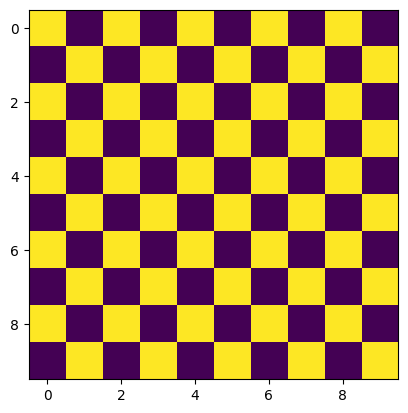

In [ ]:

m=10
n=10
N=m*n

h, v, d = patrones_balanceados(m, n)
plt.imshow(d)

In [ ]:
d

array([[ 1, -1,  1, -1,  1, -1,  1, -1,  1, -1],
       [-1,  1, -1,  1, -1,  1, -1,  1, -1,  1],
       [ 1, -1,  1, -1,  1, -1,  1, -1,  1, -1],
       [-1,  1, -1,  1, -1,  1, -1,  1, -1,  1],
       [ 1, -1,  1, -1,  1, -1,  1, -1,  1, -1],
       [-1,  1, -1,  1, -1,  1, -1,  1, -1,  1],
       [ 1, -1,  1, -1,  1, -1,  1, -1,  1, -1],
       [-1,  1, -1,  1, -1,  1, -1,  1, -1,  1],
       [ 1, -1,  1, -1,  1, -1,  1, -1,  1, -1],
       [-1,  1, -1,  1, -1,  1, -1,  1, -1,  1]])

In [ ]:
psi=np.concatenate



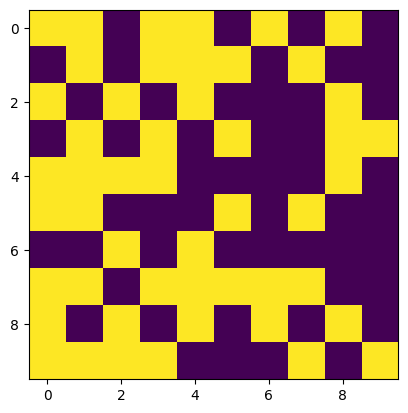

In [ ]:
s_ruido = agregar_ruido(np.concat(d), frac=0.25, seed=10)
plt.imshow(np.reshape(s_ruido, (m, n)))

In [ ]:
#estado=np.concatenate(d)


In [ ]:
estado=np.concatenate(d).reshape(N,1) # estado
psi=d.flatten().reshape(1,N)

def pesos_ij(psi,N):
  w=np.zeros((N,N))
  for i in range(0,N):
    for j in range(0,N):
      if (i !=j):
        w[i,j]=psi[0][i]*psi[0][j]
  return w

W_ij=pesos_ij(psi,N)


In [ ]:
#campo=(W_ij@estado).T
#energia_i=-0.5*estado.T@W_ij@estado
#energia_i
#campo=W_ij@estado
#estado*campo*0.5
#campo

In [ ]:
estado=np.concatenate(d).reshape(N,1)
np.shape(estado)
def campo_local(W_ij,estado):
  campo= W_ij@estado
  return campo
def EnergiaTotal(estado,H):
  return -0.5*(estado.T@H)

h=campo_local(W_ij,estado)
EnergiaTotal(estado,h)


array([[-4950.]])

In [ ]:
s_ruido=s_ruido.reshape( N,1)
for i in range(0,400):
  h=campo_local(W_ij,s_ruido)
  index=np.random.randint(0,N)
  direccion=np.sign(h[index])
  if(direccion>0):
    s_ruido[index]=1
  else:
    s_ruido[index]=-1
h=campo_local(W_ij,s_ruido)
EnergiaTotal(s_ruido,h)






array([[-4950.]])

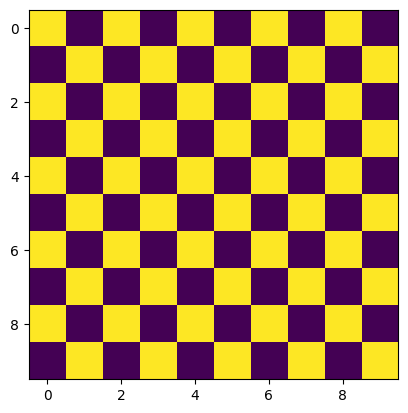

In [ ]:
plt.imshow(s_ruido.reshape(n,m))

In [ ]:
#energiaTotal=np.sum(energia_i)
#energiaTotal

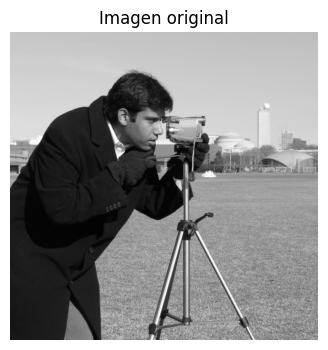

(512, 512)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.transform import resize
from skimage.color import rgb2gray

img = data.camera()   # imagen 512x512 en escala de grises

plt.figure(figsize=(4,4))
plt.imshow(img, cmap="gray")
plt.title("Imagen original")
plt.axis("off")
plt.show()
print(img.shape)

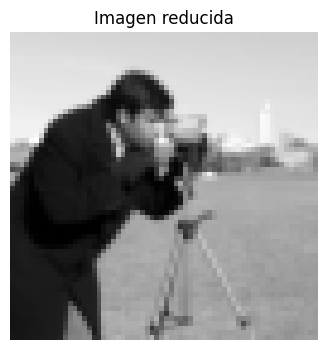

(64, 64)
0.014974712225696275
0.919128406389873
float64


In [ ]:
# ============================================================
# Reducir imagen
# ============================================================

n = 64
m = 64

img_small = resize(img, (n, m), anti_aliasing=True)

plt.figure(figsize=(4,4))
plt.imshow(img_small, cmap="gray")
plt.title("Imagen reducida")
plt.axis("off")
plt.show()
print(img_small.shape)
print(img_small.min())
print(img_small.max())
print(img_small.dtype)

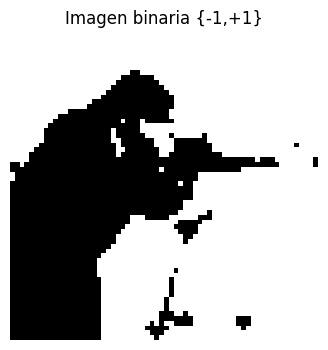

[-1  1]
(64, 64)


In [ ]:
# ============================================================
# Binarización
# ============================================================

threshold = img_small.mean()

img_bin = np.where(img_small > threshold, 1, -1)

plt.figure(figsize=(4,4))
plt.imshow(img_bin, cmap="gray")
plt.title("Imagen binaria {-1,+1}")
plt.axis("off")
plt.show()
print(np.unique(img_bin))
print(img_bin.shape)

In [ ]:
img_bin

array([[ 1,  1,  1, ...,  1,  1,  1],
       [ 1,  1,  1, ...,  1,  1,  1],
       [ 1,  1,  1, ...,  1,  1,  1],
       ...,
       [-1, -1, -1, ...,  1,  1,  1],
       [-1, -1, -1, ...,  1,  1,  1],
       [-1, -1, -1, ...,  1,  1,  1]])

In [ ]:
# ============================================================
# Ruido
# ============================================================

def agregar_ruido(s, frac=0.30, seed=None):
    if seed is not None:
        np.random.seed(seed)

    s_ruido = s.copy()
    N = len(s)

    n_flip = int(frac * N)
    idx = np.random.choice(N, n_flip, replace=False)

    s_ruido[idx] *= -1

    return s_ruido


frac_ruido = 0.30

s_ruido = agregar_ruido(np.concat(img_bin), frac=frac_ruido, seed=123)
s_original = img_bin.flatten()

print("Número de píxeles:", len(s_original))
print("Píxeles modificados:", np.sum(s_original != s_ruido))


Número de píxeles: 4096
Píxeles modificados: 1228


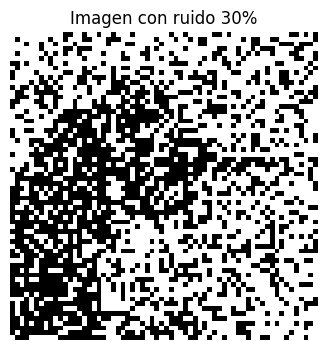

In [ ]:
plt.figure(figsize=(4,4))
plt.imshow(s_ruido.reshape(n, m), cmap="gray")
plt.title(f"Imagen con ruido {frac_ruido*100:.0f}%")
plt.axis("off")
plt.show()

In [ ]:
# ============================================================
# Preparar patrón original y estado inicial con ruido
# ============================================================

# Patrón original que la red debe almacenar
patron = img_bin.flatten()

# Estado inicial desde el cual comenzará la reconstrucción
estado_inicial = s_ruido.copy()

# Número de neuronas
N = len(patron)

print("Número de neuronas:", N)
print("Forma del patrón original:", patron.shape)
print("Forma del estado con ruido:", estado_inicial.shape)
print("Estados del patrón:", np.unique(patron))
print("Estados con ruido:", np.unique(estado_inicial))

Número de neuronas: 4096
Forma del patrón original: (4096,)
Forma del estado con ruido: (4096,)
Estados del patrón: [-1  1]
Estados con ruido: [-1  1]


In [ ]:
# ============================================================
# Construcción de la matriz de pesos de Hopfield
# ============================================================

W = np.outer(patron, patron) / N

# Eliminar autoconexiones
np.fill_diagonal(W, 0)

print("Forma de W:", W.shape)
print("W es simétrica:", np.allclose(W, W.T))
print("Diagonal nula:", np.allclose(np.diag(W), 0))

Forma de W: (4096, 4096)
W es simétrica: True
Diagonal nula: True


In [ ]:
# ============================================================
# Campo local
# ============================================================

def campo_local(W, estado):
    h = W @ estado
    return h

# Campo local de la imagen con ruido
h_inicial = campo_local(W, estado_inicial)

print("Forma del campo local:", h_inicial.shape)
print("Primeros 10 valores de h:")
print(h_inicial[:10])
direccion_correcta = np.sign(h_inicial) == patron

print(
    "Campos apuntando al patrón original:",
    np.sum(direccion_correcta),
    "de",
    N
)

Forma del campo local: (4096,)
Primeros 10 valores de h:
[0.40014648 0.40014648 0.40014648 0.40014648 0.40014648 0.40014648
 0.40014648 0.40014648 0.40014648 0.40014648]
Campos apuntando al patrón original: 4096 de 4096


In [ ]:
# ============================================================
# Actualización de una neurona
# ============================================================

def actualizar_neurona(estado, W, i):

    # Calcular el campo local de la neurona i
    h_i = W[i] @ estado

    # Actualizar el estado de la neurona
    if h_i > 0:
        estado[i] = 1
    elif h_i < 0:
        estado[i] = -1

    # Si h_i = 0, la neurona conserva su estado

    return estado

In [ ]:
# ============================================================
# Energía total de la red de Hopfield
# ============================================================

def energia_total(estado, W):
    E = -0.5 * estado @ W @ estado
    return E


# Energía inicial de la imagen con ruido
E_inicial = energia_total(estado_inicial, W)

print("Energía inicial:", E_inicial)

Energía inicial: -327.8203125


In [ ]:
# ============================================================
# Reconstrucción asíncrona
# ============================================================

def reconstruir_hopfield(estado_inicial, W, max_iter=20000, seed=123):

    np.random.seed(seed)

    # Copia para no modificar el estado inicial
    estado = estado_inicial.copy()

    # Guardamos la energía durante la evolución
    energias = [energia_total(estado, W)]

    N = len(estado)

    for paso in range(max_iter):

        # Elegir aleatoriamente una neurona
        i = np.random.randint(0, N)

        # Actualizar únicamente esa neurona
        actualizar_neurona(estado, W, i)

        # Guardar la energía
        energias.append(energia_total(estado, W))

    return estado, np.array(energias)

In [ ]:
# ============================================================
# Ejecutar reconstrucción
# ============================================================

estado_recuperado, energias = reconstruir_hopfield(
    estado_inicial,
    W,
    max_iter=20000,
    seed=123
)

print("Energía inicial:", energias[0])
print("Energía final:", energias[-1])

pixeles_correctos = np.sum(estado_recuperado == patron)
porcentaje_recuperado = 100 * pixeles_correctos / N

print("Píxeles correctos:", pixeles_correctos, "de", N)
print(f"Recuperación: {porcentaje_recuperado:.2f}%")

Energía inicial: -327.8203125
Energía final: -2013.64111328125
Píxeles correctos: 4079 de 4096
Recuperación: 99.58%


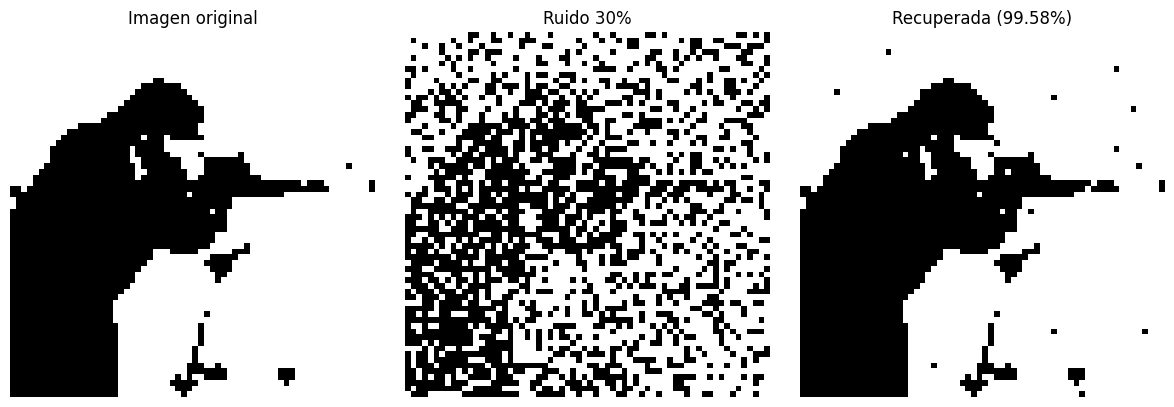

In [ ]:
# ============================================================
# Comparación visual
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Imagen original
axes[0].imshow(patron.reshape(n, m), cmap="gray")
axes[0].set_title("Imagen original")
axes[0].axis("off")

# Imagen con ruido
axes[1].imshow(estado_inicial.reshape(n, m), cmap="gray")
axes[1].set_title(f"Ruido {frac_ruido*100:.0f}%")
axes[1].axis("off")

# Imagen recuperada
axes[2].imshow(estado_recuperado.reshape(n, m), cmap="gray")
axes[2].set_title(f"Recuperada ({porcentaje_recuperado:.2f}%)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

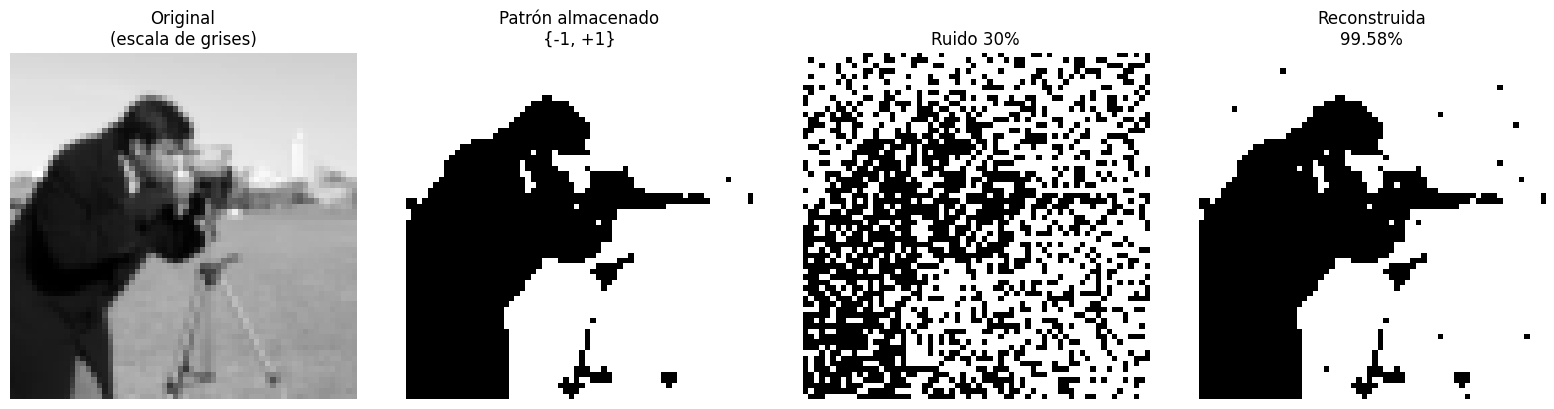

In [ ]:
# ============================================================
# Comparación final de la reconstrucción
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Imagen original reducida en escala de grises
axes[0].imshow(img_small, cmap="gray")
axes[0].set_title("Original\n(escala de grises)")
axes[0].axis("off")

# Imagen binaria almacenada
axes[1].imshow(img_bin, cmap="gray")
axes[1].set_title("Patrón almacenado\n{-1, +1}")
axes[1].axis("off")

# Imagen con ruido
axes[2].imshow(estado_inicial.reshape(n, m), cmap="gray")
axes[2].set_title(f"Ruido {frac_ruido*100:.0f}%")
axes[2].axis("off")

# Imagen reconstruida
axes[3].imshow(estado_recuperado.reshape(n, m), cmap="gray")
axes[3].set_title(f"Reconstruida\n{porcentaje_recuperado:.2f}%")
axes[3].axis("off")

plt.tight_layout()
plt.show()

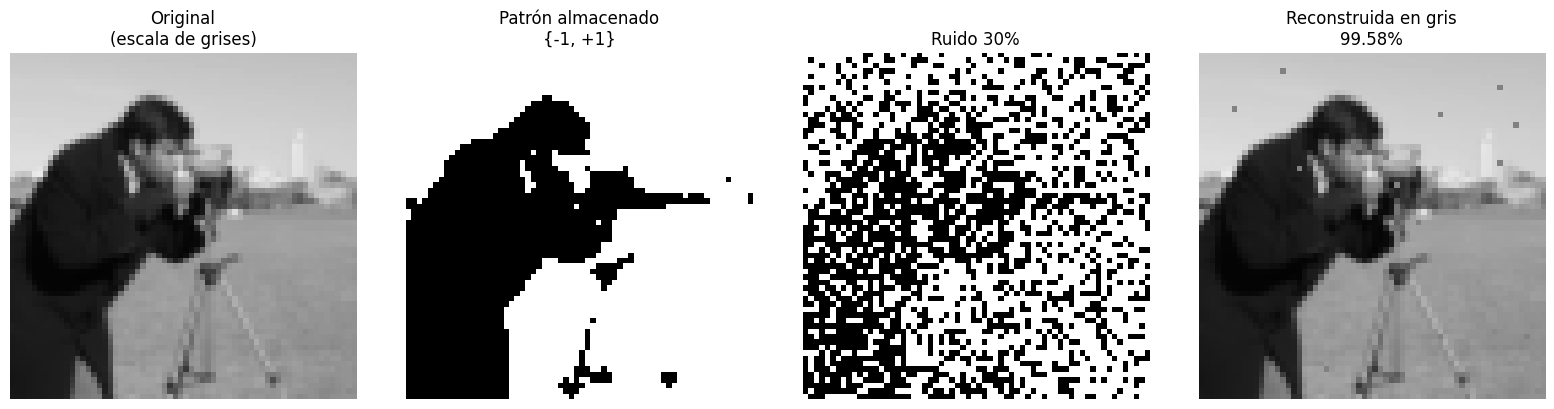

In [ ]:
# ============================================================
# Reconstrucción visual en escala de grises
# ============================================================

# Volver a forma 64x64
mascara_recuperada = estado_recuperado.reshape(n, m)

# Crear imagen reconstruida en escala de grises
img_reconstruida_gray = img_small.copy()

# Aplicar la clasificación recuperada por Hopfield
img_reconstruida_gray[mascara_recuperada == 1] = np.maximum(
    img_reconstruida_gray[mascara_recuperada == 1],
    threshold
)

img_reconstruida_gray[mascara_recuperada == -1] = np.minimum(
    img_reconstruida_gray[mascara_recuperada == -1],
    threshold
)

# ============================================================
# Comparación
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original
axes[0].imshow(img_small, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original\n(escala de grises)")
axes[0].axis("off")

# Patrón almacenado
axes[1].imshow(img_bin, cmap="gray")
axes[1].set_title("Patrón almacenado\n{-1, +1}")
axes[1].axis("off")

# Imagen con ruido
axes[2].imshow(estado_inicial.reshape(n, m), cmap="gray")
axes[2].set_title(f"Ruido {frac_ruido*100:.0f}%")
axes[2].axis("off")

# Reconstruida en escala de grises
axes[3].imshow(img_reconstruida_gray, cmap="gray", vmin=0, vmax=1)
axes[3].set_title(
    f"Reconstruida en gris\n{porcentaje_recuperado:.2f}%"
)
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Reconstrucción de Hopfield hasta la convergencia
# ============================================================

def reconstruir_hasta_convergencia(estado_inicial, W, max_barridos=20, seed=123):

    rng = np.random.default_rng(seed)

    estado = estado_inicial.copy()
    N = len(estado)

    for barrido in range(max_barridos):

        cambios = 0

        # Visitar todas las neuronas en orden aleatorio
        indices = rng.permutation(N)

        for i in indices:

            valor_anterior = estado[i]

            actualizar_neurona(estado, W, i)

            if estado[i] != valor_anterior:
                cambios += 1

        print(f"Barrido {barrido + 1}: {cambios} cambios")

        # Si ninguna neurona cambia, alcanzamos un estado estable
        if cambios == 0:
            print("La red ha convergido.")
            break

    return estado


# Ejecutar reconstrucción
estado_recuperado = reconstruir_hasta_convergencia(
    estado_inicial, W
)

# Evaluar resultado
porcentaje_recuperado = 100 * np.mean(estado_recuperado == patron)

print(f"\nRecuperación final: {porcentaje_recuperado:.2f}%")
print("Píxeles incorrectos:", np.sum(estado_recuperado != patron))

Barrido 1: 1228 cambios
Barrido 2: 0 cambios
La red ha convergido.

Recuperación final: 100.00%
Píxeles incorrectos: 0


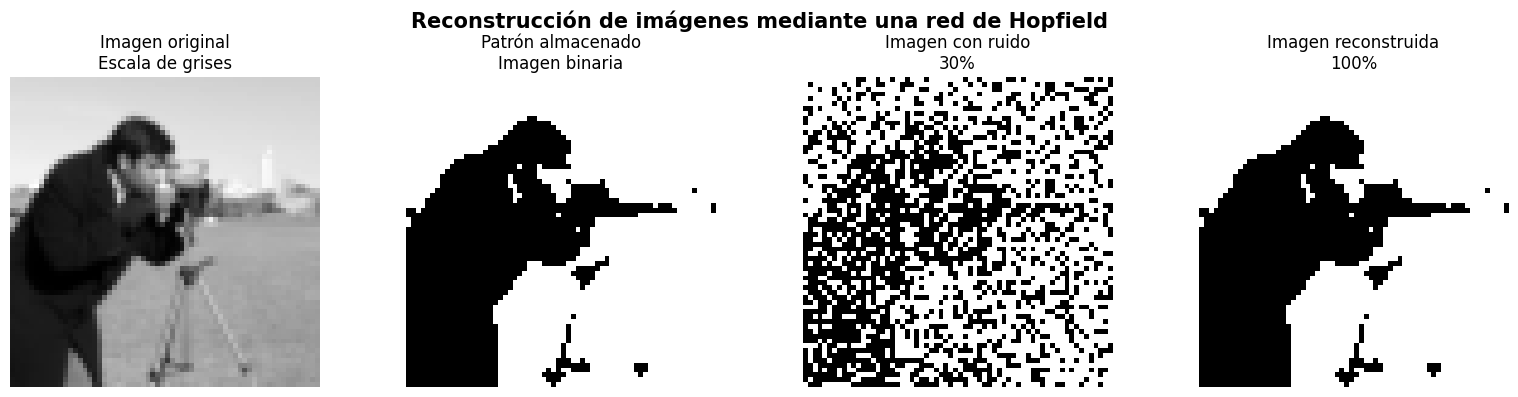

¿La reconstrucción es idéntica al patrón almacenado?
True


In [ ]:
# ============================================================
# Resultado final de la reconstrucción con Hopfield
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

imagenes = [
    img_small,
    img_bin,
    estado_inicial.reshape(n, m),
    estado_recuperado.reshape(n, m)
]

titulos = [
    "Imagen original\nEscala de grises",
    "Patrón almacenado\nImagen binaria",
    "Imagen con ruido\n30%",
    "Imagen reconstruida\n100%"
]

for ax, imagen, titulo in zip(axes, imagenes, titulos):
    ax.imshow(imagen, cmap="gray", interpolation="nearest")
    ax.set_title(titulo, fontsize=12)
    ax.axis("off")

plt.suptitle(
    "Reconstrucción de imágenes mediante una red de Hopfield",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Verificación final
print("¿La reconstrucción es idéntica al patrón almacenado?")
print(np.array_equal(estado_recuperado, patron))


# Preguntas guía — Laboratorio de memorias asociativas con redes de Hopfield

## 1. ¿La energía disminuye durante la recuperación?

Sí. En una red de Hopfield clásica, con una matriz de pesos simétrica, diagonal nula y actualizaciones asíncronas deterministas, la energía no aumenta durante la evolución.

La energía de la red está definida por:

$$
E(\mathbf{s})=-\frac{1}{2}\mathbf{s}^{T}W\mathbf{s}.
$$

En nuestro experimento obtuvimos:

- **Energía inicial:** $E_i=-327.8203125$
- **Energía después de 20000 actualizaciones:** $E_f=-2013.64111328125$

Por tanto:

$$
E_f<E_i.
$$

Este resultado muestra que la red evolucionó hacia una configuración de menor energía, acercándose al patrón almacenado.

La disminución de energía se explica porque cada neurona actualiza su estado de acuerdo con el campo local generado por las demás neuronas.

Es importante señalar que la energía no necesariamente disminuye en cada actualización; también puede permanecer constante cuando una neurona ya se encuentra en su estado adecuado.

**Conclusión:** los resultados son consistentes con la propiedad de descenso de energía de Hopfield, que permite interpretar la recuperación como una evolución hacia un estado estable.

---

## 2. ¿La red recupera exactamente la imagen original?

Sí. En nuestro experimento conseguimos recuperar exactamente el patrón binario almacenado.

La imagen utilizada tenía dimensiones de:

$$
64\times64=4096\text{ píxeles}.
$$

Introdujimos un nivel de ruido del $30\%$, equivalente a invertir 1228 píxeles.

Inicialmente, después de 20000 actualizaciones aleatorias, obtuvimos:

- **Recuperación:** $99.58\%$
- **Píxeles correctos:** 4079
- **Píxeles incorrectos:** 17

Posteriormente, implementamos una reconstrucción mediante barridos completos en orden aleatorio.

Los resultados fueron:

| Barrido | Neuronas que cambiaron |
|---|---:|
| 1 | 1228 |
| 2 | 0 |

La recuperación final fue:

$$
\boxed{\text{Recuperación}=100\%}
$$

Esto significa que la red corrigió todos los píxeles alterados y alcanzó un estado estable idéntico al patrón almacenado.

Sin embargo, debemos aclarar que la red reconstruyó la imagen **binaria**, no los niveles originales de gris, ya que estos se perdieron durante la binarización.

---

## 3. ¿Qué ocurre si aumenta el nivel de ruido?

Cuando aumenta el nivel de ruido, también aumenta la cantidad de píxeles que no coinciden con la imagen almacenada. Esto reduce la información correcta disponible para que la red identifique la memoria original.

La recuperación depende de que el estado inicial se encuentre dentro de la región de atracción del patrón almacenado.

En nuestro experimento utilizamos un ruido del $30\%$ y logramos una recuperación completa.

Para comprender el efecto de aumentar el ruido, consideremos el campo local para una sola memoria:

$$
h_i=\frac{\xi_i}{N}\sum_{j\neq i}\xi_j s_j.
$$

Si una fracción $f$ de los píxeles se encuentra invertida, la coincidencia normalizada entre el estado perturbado y el patrón original es:

$$
m=1-2f.
$$

Por ejemplo:

| Nivel de ruido | Coincidencia inicial |
|---|---:|
| 10 % | 0.8 |
| 20 % | 0.6 |
| 30 % | 0.4 |
| 40 % | 0.2 |
| 50 % | 0 |
| 60 % | -0.2 |

En nuestro modelo particular, donde almacenamos una sola imagen, cuando el ruido supera aproximadamente el $50\%$, el estado inicial puede encontrarse más relacionado con el patrón opuesto que con el original.

Esto se debe a que el patrón invertido globalmente, $-\boldsymbol{\xi}$, también constituye un estado estable de la red.

**Conclusión:** al aumentar el ruido, la recuperación puede volverse más difícil y eventualmente conducir a un patrón diferente. Para determinar experimentalmente el comportamiento de nuestra red con otros porcentajes, sería necesario realizar nuevas simulaciones.

---

## 4. ¿Qué pasa si se almacenan varias imágenes?

Cuando almacenamos varias imágenes, la red utiliza una única matriz de pesos que contiene información de todos los patrones.

La regla de aprendizaje de Hebb es:

$$
w_{ij}=\frac{1}{N}\sum_{\mu=1}^{P}\xi_i^\mu\xi_j^\mu,
\qquad w_{ii}=0.
$$

Donde:

- $N$ representa el número de neuronas.
- $P$ representa el número de imágenes almacenadas.
- $\xi_i^\mu$ representa el estado de la neurona $i$ en el patrón $\mu$.

Esto permite que la red reconozca diferentes imágenes a partir de versiones incompletas o perturbadas.

Sin embargo, cuando aumenta el número de memorias también pueden aparecer interferencias entre los patrones.

Si las imágenes son muy similares o se almacenan demasiadas, la red puede confundirlas y disminuir su precisión.

Para patrones aleatorios independientes y aproximadamente no correlacionados, la capacidad clásica aproximada es:

$$
P_c\approx0.138N.
$$

En nuestro caso:

$$
P_c\approx0.138(4096)\approx565.
$$

Este resultado es una estimación teórica y no significa que podamos almacenar 565 fotografías reales garantizando su recuperación perfecta.

**Conclusión:** almacenar varias imágenes aumenta la capacidad asociativa de la red, pero también introduce interferencias que pueden afectar la recuperación.

---

## 5. ¿Aparecen estados espurios?

Los estados espurios son configuraciones estables de la red que no corresponden a las imágenes que se pretendía almacenar.

Estos estados pueden aparecer debido a la interacción entre diferentes memorias y a la existencia de mínimos adicionales en el paisaje de energía.

Cuando se almacenan varios patrones, algunas combinaciones de ellos pueden producir configuraciones estables diferentes de las memorias originales.

En nuestro experimento almacenamos una sola imagen y conseguimos reconstruirla completamente.

Por tanto, **no observamos una recuperación hacia un estado espurio**.

Sin embargo, esto no demuestra que la red carezca de otros estados estables.

Por ejemplo, para la regla de Hebb utilizada, el patrón opuesto:

$$
-\boldsymbol{\xi}
$$

también constituye un estado estable.

**Conclusión:** los estados espurios representan una limitación de las redes de Hopfield, especialmente cuando se almacenan múltiples memorias. En nuestro experimento no observamos que la recuperación terminara en uno de estos estados.

---

## 6. ¿La recuperación depende del orden en que se actualizan los píxeles?

Sí. En general, el orden de actualización puede influir en la trayectoria de evolución y, cuando existen varios atractores, también en el estado final.

En la actualización asíncrona, cada neurona utiliza la configuración más reciente de la red.

Por tanto, modificar una neurona puede cambiar los campos locales que experimentarán las siguientes.

En nuestro laboratorio utilizamos dos procedimientos.

**Primer procedimiento:**

Seleccionamos neuronas aleatoriamente con reemplazo y realizamos 20000 actualizaciones.

Obtuvimos:

$$
\text{Recuperación}=99.58\%.
$$

**Segundo procedimiento:**

Realizamos barridos completos, visitando todas las neuronas exactamente una vez por barrido, en orden aleatorio.

Obtuvimos:

$$
\text{Recuperación}=100\%.
$$

Esto muestra la importancia del procedimiento de actualización y del criterio de parada.

Sin embargo, no podemos atribuir la diferencia exclusivamente al orden, porque también modificamos la forma de seleccionar las neuronas y el criterio de convergencia.

En nuestro caso particular, los campos locales iniciales de las 4096 neuronas apuntaban hacia el patrón original. Por ello, un barrido completo permitió corregir todos los píxeles alterados.

**Conclusión:** el orden de actualización puede afectar la evolución de la red, aunque en nuestro experimento la recuperación completa se consiguió al garantizar que todas las neuronas fueran actualizadas.

---

## 7. ¿Qué diferencia hay entre actualización sincrónica y asincrónica?

La diferencia fundamental consiste en el momento en que se actualizan los estados de las neuronas.

### Actualización sincrónica

En este procedimiento, todas las neuronas calculan sus nuevos estados utilizando la configuración anterior de la red.

La regla es:

$$
s_i(t+1)=\operatorname{sign}
\left(
\sum_j w_{ij}s_j(t)
\right).
$$

Todas las neuronas se actualizan simultáneamente.

Este procedimiento permite realizar actualizaciones mediante operaciones matriciales, pero la energía convencional de Hopfield no necesariamente disminuye en cada paso.

Además, pueden aparecer oscilaciones entre configuraciones, como ciclos de período dos.

### Actualización asincrónica

En este procedimiento, las neuronas se actualizan individualmente.

Después de modificar una neurona, su nuevo estado se utiliza inmediatamente en las siguientes actualizaciones.

La regla es:

$$
s_i\leftarrow\operatorname{sign}
\left(
\sum_j w_{ij}s_j
\right).
$$

Con una matriz de pesos simétrica, diagonal nula y conservando el estado cuando el campo es cero, la energía no aumenta durante las actualizaciones asíncronas.

Esta fue la estrategia utilizada en nuestro laboratorio.

### Comparación

| Característica | Sincrónica | Asincrónica |
|---|---|---|
| Actualización | Todas las neuronas simultáneamente | Una neurona por vez |
| Información utilizada | Estado anterior completo | Estado más reciente |
| Energía convencional | Puede aumentar | No aumenta |
| Oscilaciones | Puede presentar ciclos | No presenta ciclos de cambio con aumento de energía |
| Método utilizado en el laboratorio | No | Sí |

**Conclusión:** la actualización asíncrona favorece una evolución controlada hacia estados estables, por lo que resulta especialmente apropiada para estudiar la recuperación de memorias en una red de Hopfield clásica.

---

## Conclusión general

El laboratorio permitió estudiar el funcionamiento de una red de Hopfield como sistema de memoria asociativa.

Utilizamos una imagen de $64\times64$ píxeles, equivalente a 4096 neuronas, y construimos una matriz de pesos mediante la regla de aprendizaje de Hebb.

Posteriormente, introdujimos un nivel de ruido del $30\%$, invirtiendo 1228 píxeles de la imagen binaria.

Mediante actualizaciones asíncronas, la red consiguió recuperar el patrón almacenado con una precisión final del:

$$
\boxed{100\%}
$$

Los resultados muestran que la red puede recuperar información a partir de una versión perturbada y alcanzar un estado estable.

También observamos una disminución de la energía durante la recuperación, consistente con la dinámica característica de Hopfield.

Finalmente, el experimento permitió comprender algunas limitaciones del modelo, como la pérdida de información durante la binarización, la interferencia entre memorias y la posible aparición de estados espurios.

En conjunto, estos resultados ilustran cómo una red neuronal recurrente puede almacenar información distribuida en sus conexiones y utilizarla posteriormente para reconstruir patrones incompletos o alterados.

**Nota:** las conclusiones sobre la recuperación con $30\%$ de ruido y el descenso de energía están respaldadas por nuestras simulaciones. Los comportamientos relacionados con niveles mayores de ruido, múltiples memorias y actualización sincrónica se explicaron teóricamente, pero no fueron evaluados experimentalmente en este ejercicio.
